# Wafer 영역 mask 레이어 실험

이 노트북은 `modeling.ipynb`의 실험 5를 바탕으로, mask 채널만 원래 의도에 맞게 수정한 별도 실험입니다.

- 기존 방식: resize 후 padding을 제외한 **유효 사각형 전체**를 1로 표시
- 이 노트북: `portfolio_wafer_visuals.ipynb`와 동일하게 padding된 wafer map에서 **값이 0보다 큰 실제 wafer 위치**만 1로 표시
- 입력 채널: 채널 0은 기존처럼 `wafer_map / 2.0`, 채널 1은 binary wafer 영역 mask
- 비교 조건: 기존 실험 5와 동일한 oversampling 및 augmentation 설정
- 격리 원칙: 원본 노트북, `data`, 기존 `checkpoints`, 기존 `results.csv`를 수정하지 않음

아래 환경 설정은 로컬에서는 이 노트북이 있는 `notebooks` 디렉터리를 기준으로 사용합니다. Colab에서는 Google Drive를 마운트한 뒤 `DRIVE_PROJECT_DIR`에서 데이터 위치를 찾습니다.


In [6]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU 없음")

True
Tesla T4


In [8]:
from __future__ import annotations

import importlib.util
from pathlib import Path

IS_COLAB = (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
)
LOCAL_NOTEBOOK_PATH = Path(
    r"C:\Users\ATSAdmin\OneDrive\07_SKALA\lecture\13_MLOps\MLOps_wafer\notebooks\modeling_wafer_area_mask_experiment.ipynb"
).resolve()
DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2"
)


if IS_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    candidates = [DRIVE_PROJECT_DIR, DRIVE_PROJECT_DIR / "notebooks"]
    WORK_DIR = next(
        (path for path in candidates if (path / "data" / "LSWMD.pkl").is_file()),
        None,
    )
    if WORK_DIR is None:
        checked_paths = "\n".join(str(path) for path in candidates)
        raise FileNotFoundError(
            f"Google Drive에서 data/LSWMD.pkl을 찾지 못했습니다:\n{checked_paths}"
        )
else:
    WORK_DIR = LOCAL_NOTEBOOK_PATH.parent

DATA_PATH = WORK_DIR / "data" / "LSWMD.pkl"

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"데이터 파일을 찾지 못했습니다: {DATA_PATH}")

ARTIFACT_DIR = WORK_DIR / "mask_wafer_area_experiment"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
RESULTS_PATH = ARTIFACT_DIR / "results_wafer_area_mask.csv"

print(f"실행 환경: {'Colab' if IS_COLAB else 'Local'}")
print(f"작업 디렉터리: {WORK_DIR}")
print(f"새 결과 저장 위치: {ARTIFACT_DIR}")


Mounted at /content/drive
실행 환경: Colab
작업 디렉터리: /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2
새 결과 저장 위치: /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/mask_wafer_area_experiment


In [11]:
import subprocess
import sys


if IS_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "pandas",
            "numpy",
            "scikit-learn",
            "seaborn",
            "matplotlib",
            "torchvision",
            "Pillow",
            "torchsummary",
            "opencv-python",
        ]
    )
else:
    print("로컬 환경에서는 기존 Python 환경을 사용하므로 설치를 건너뜁니다.")


## train/test데이터셋 구분

In [12]:
import pandas as pd
import numpy as np

In [13]:
df = pd.read_pickle(DATA_PATH)
df = df.rename(columns={'trianTestLabel':'trainTestLabel'})
df.head()

,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [14]:
df['failureType'] = df['failureType'].apply(lambda x: x[0][0] if isinstance(x, np.ndarray) and x.size > 0 else np.str_('unknown'))
df['trainTestLabel'] = df['trainTestLabel'].apply(lambda x: x[0][0] if isinstance(x, np.ndarray) and x.size > 0 else np.str_('unknown'))
df_notnull = df[(df['failureType'] != 'unknown') & (df['trainTestLabel'] != 'unknown')]

print(df_notnull.shape)
df_notnull.head()

(172950, 6)


,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,Training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,Training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,Training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,Training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,Training,none


In [15]:
df_train = df[df['trainTestLabel'] == 'Training']
print(df_train.shape)
print(df_train['failureType'].value_counts())
df_train.head()

(54355, 6)
failureType
none         36730
Edge-Ring     8554
Center        3462
Edge-Loc      2417
Loc           1620
Random         609
Scratch        500
Donut          409
Near-full       54
Name: count, dtype: int64


,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,Training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,Training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,Training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,Training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,Training,none


In [16]:
df_test = df[df['trainTestLabel'] == 'Test']
print(df_test.shape)
print(df_test['failureType'].value_counts())
df_test.head()

(118595, 6)
failureType
none         110701
Edge-Loc       2772
Loc            1973
Edge-Ring      1126
Center          832
Scratch         693
Random          257
Donut           146
Near-full        95
Name: count, dtype: int64


,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
639663,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2,...",533.0,lot40328,1.0,Test,none
639664,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1,...",533.0,lot40328,2.0,Test,none
639665,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2,...",533.0,lot40328,3.0,Test,none
639666,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 2,...",533.0,lot40328,4.0,Test,none
639667,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1, 1,...",533.0,lot40328,5.0,Test,none


failureType을 id화하고, 불필요한 column 제거

In [17]:
import pandas as pd


CLASSES = [
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
    "none",
]

LABEL2ID = {label: idx for idx, label in enumerate(CLASSES)}
ID2LABEL = {idx: label for idx, label in enumerate(CLASSES)}


def preprocess_wafer_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """웨이퍼 원본 데이터프레임을 학습용 형태로 전처리합니다.

    수행 내용:
        1. 학습에 필요한 컬럼만 선택
        2. failureType 문자열 라벨을 label_id 정수 라벨로 변환
        3. 라벨 매핑 불가 행 제거
        4. 인덱스 재정렬

    Args:
        df: 원본 웨이퍼 데이터프레임.

    Returns:
        학습용 전처리가 완료된 데이터프레임.
    """
    required_columns = [
        "waferMap",
        "lotName",
        "failureType",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in df.columns
    ]
    if missing_columns:
        raise ValueError(f"필수 컬럼이 없습니다: {missing_columns}")

    processed_df = df[required_columns].copy()

    processed_df["label_id"] = processed_df["failureType"].map(LABEL2ID)

    processed_df = processed_df.dropna(subset=["label_id"]).copy()
    processed_df["label_id"] = processed_df["label_id"].astype(int)

    processed_df = processed_df.reset_index(drop=True)

    return processed_df

In [18]:
wafer_df = preprocess_wafer_dataframe(df_notnull)

print(wafer_df["failureType"].value_counts(), "\n")
print(wafer_df["label_id"].value_counts().sort_index(), "\n")
wafer_df.head()

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64 

label_id
0      4294
1       555
2      5189
3      9680
4      3593
5       866
6      1193
7       149
8    147431
Name: count, dtype: int64 



,waferMap,lotName,failureType,label_id
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,none,8
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,none,8
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,none,8
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,none,8
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot1,none,8


### 중간 데이터는 파일로 저장하지 않음

기존 `data` 파일을 보호하기 위해 전처리 데이터프레임은 메모리에서만 사용합니다.


기존에 부여된 test/train 레이블 상 test가 train보다 많은 상황 <br>
두 개를 합쳐서 하나의 데이터셋으로 만든 다음, 10%정도를 test로 만들고자 함 <br>
이 때 층화추출을 통해서 기존의 데이터셋 불균형을 반영하려 함 <br>

In [19]:
from sklearn.model_selection import train_test_split

def rebuild_train_test_with_stratification(
    df: pd.DataFrame,
    stratify_col: str,
    test_size: float = 0.1,
    random_state: int = 42,
    label_col: str = "trainTestLabel",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """전체 데이터셋을 다시 train/test로 층화 분할합니다.

    기존 train/test 레이블은 무시하고, 전체 데이터를 하나로 합친 뒤
    지정한 stratify_col의 클래스 비율을 유지하도록 층화추출하여
    새로운 train/test 세트를 생성합니다.

    Args:
        df: 원본 데이터프레임.
        stratify_col: 층화 기준이 될 컬럼명.
        test_size: 테스트셋 비율.
        random_state: 재현성을 위한 시드 값.
        label_col: 새로 부여할 train/test 레이블 컬럼명.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
            - train_df: 새로 분할된 train 데이터
            - test_df: 새로 분할된 test 데이터
            - df_new: train/test 레이블이 다시 부여된 전체 데이터
    """
    df_all = df.copy().reset_index(drop=True)

    train_idx, test_idx = train_test_split(
        df_all.index,
        test_size=test_size,
        random_state=random_state,
        stratify=df_all[stratify_col],
    )

    train_df = df_all.loc[train_idx].copy()
    test_df = df_all.loc[test_idx].copy()

    train_df[label_col] = "Training"
    test_df[label_col] = "Test"

    df_new = pd.concat([train_df, test_df], axis=0).sort_index().reset_index(drop=True)
    train_df.drop(columns=[label_col], inplace=True)
    test_df.drop(columns=[label_col], inplace=True)

    return train_df, test_df, df_new

train / test 데이터셋 구분

In [20]:
train_df, test_df, df_rebuilt = rebuild_train_test_with_stratification(
    df=wafer_df,
    stratify_col="label_id",
    test_size=0.1,
    random_state=42,
    label_col="trainTestLabel",
)

In [21]:
print("전체 개수:", len(df_rebuilt))
print("Train 개수:", len(train_df))
print("Test 개수:", len(test_df))

print("\n[전체 failureType 비율]")
print(df_rebuilt["failureType"].value_counts(normalize=True))

print("\n[Train failureType 비율]")
print(train_df["failureType"].value_counts(normalize=True))

print("\n[Test failureType 비율]")
print(test_df["failureType"].value_counts(normalize=True))

print("\n[새 trainTestLabel 분포]")
print(df_rebuilt["trainTestLabel"].value_counts())

전체 개수: 172950
Train 개수: 155655
Test 개수: 17295

[전체 failureType 비율]
failureType
none         0.852449
Edge-Ring    0.055970
Edge-Loc     0.030003
Center       0.024828
Loc          0.020775
Scratch      0.006898
Random       0.005007
Donut        0.003209
Near-full    0.000862
Name: proportion, dtype: float64

[Train failureType 비율]
failureType
none         0.852449
Edge-Ring    0.055970
Edge-Loc     0.030002
Center       0.024831
Loc          0.020777
Scratch      0.006900
Random       0.005005
Donut        0.003206
Near-full    0.000861
Name: proportion, dtype: float64

[Test failureType 비율]
failureType
none         0.852443
Edge-Ring    0.055970
Edge-Loc     0.030009
Center       0.024805
Loc          0.020757
Scratch      0.006881
Random       0.005030
Donut        0.003238
Near-full    0.000867
Name: proportion, dtype: float64

[새 trainTestLabel 분포]
trainTestLabel
Training    155655
Test         17295
Name: count, dtype: int64


trian / validation 데이터셋 구분

In [22]:
train_df, val_df, df_train_full = rebuild_train_test_with_stratification(
    df=train_df,
    stratify_col="label_id",
    test_size=0.1,
    random_state=42,
    label_col="trainValLabel",
)

In [23]:
print("전체 개수:", len(df_train_full))
print("Train 개수:", len(train_df))
print("Validation 개수:", len(val_df))

print("\n[전체 failureType 비율]")
print(df_train_full["failureType"].value_counts(normalize=True))

print("\n[Train failureType 비율]")
print(train_df["failureType"].value_counts(normalize=True))

print("\n[Validation failureType 비율]")
print(val_df["failureType"].value_counts(normalize=True))

print("\n[trainValLabel 분포]")
print(df_train_full["trainValLabel"].value_counts())

전체 개수: 155655
Train 개수: 140089
Validation 개수: 15566

[전체 failureType 비율]
failureType
none         0.852449
Edge-Ring    0.055970
Edge-Loc     0.030002
Center       0.024831
Loc          0.020777
Scratch      0.006900
Random       0.005005
Donut        0.003206
Near-full    0.000861
Name: proportion, dtype: float64

[Train failureType 비율]
failureType
none         0.852451
Edge-Ring    0.055972
Edge-Loc     0.030002
Center       0.024827
Loc          0.020773
Scratch      0.006903
Random       0.005004
Donut        0.003205
Near-full    0.000864
Name: proportion, dtype: float64

[Validation failureType 비율]
failureType
none         0.852435
Edge-Ring    0.055955
Edge-Loc     0.030001
Center       0.024862
Loc          0.020815
Scratch      0.006874
Random       0.005011
Donut        0.003212
Near-full    0.000835
Name: proportion, dtype: float64

[trainValLabel 분포]
trainValLabel
Training    140089
Test         15566
Name: count, dtype: int64


In [24]:
print(train_df.shape)
train_df.head()

(140089, 4)


,waferMap,lotName,failureType,label_id
113144,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot43757,none,8
129909,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,...",lot40443,none,8
139796,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 2,...",lot47083,none,8
12504,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,...",lot45578,none,8
75915,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2,...",lot46774,none,8


In [25]:
print(val_df.shape)
val_df.head()

(15566, 4)


,waferMap,lotName,failureType,label_id
112320,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1,...",lot40618,none,8
140789,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1,...",lot45190,none,8
133249,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot22476,Edge-Ring,3
27360,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...",lot42239,none,8
145408,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 2, 2,...",lot7,none,8


In [26]:
print(test_df.shape)
test_df.head()

(17295, 4)


,waferMap,lotName,failureType,label_id
106407,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",lot44658,none,8
88673,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,...",lot43877,none,8
112526,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 1,...",lot44999,none,8
149686,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,...",lot46569,none,8
149017,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,...",lot46541,none,8


## 데이터 분할 확인

In [27]:
print("분할 데이터는 메모리에서만 사용합니다.")
print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test: {len(test_df):,}")


분할 데이터는 메모리에서만 사용합니다.
Train: 140,089
Validation: 15,566
Test: 17,295


## 모델 아키텍처 정의

In [28]:
import torch
import torch.nn as nn


class SmallCNN(nn.Module):
    """웨이퍼 맵 분류를 위한 소형 CNN 모델."""

    def __init__(self, num_classes: int, in_channels: int = 1) -> None:
        """SmallCNN 초기화.

        Args:
            num_classes: 분류할 클래스 개수.
            in_channels: 입력 채널 수.
                - 일반 입력: 1
                - 이미지 + 마스크 입력: 2
        """
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),  # 256 x 1 x 1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """순전파 수행.

        Args:
            x: 입력 텐서. shape = (batch_size, in_channels, height, width)

        Returns:
            클래스 로짓 텐서.
        """
        x = self.features(x)
        x = self.classifier(x)
        return x

## 데이터셋 생성


In [29]:
import numpy as np
import torch
from torch.utils.data import Dataset
import cv2


def preprocess_fixed_resize(x: np.ndarray, target_size: int) -> np.ndarray:
    """비율 무시 고정 리사이즈를 수행합니다.

    Args:
        x: 원본 웨이퍼 맵 배열.
        target_size: 목표 이미지 크기.

    Returns:
        고정 크기로 리사이즈된 배열.
    """
    return cv2.resize(
        x,
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST,
    )


def preprocess_resize_pad(x: np.ndarray, target_size: int) -> np.ndarray:
    """비율 유지 리사이즈 후 zero padding을 수행합니다.

    Args:
        x: 원본 웨이퍼 맵 배열.
        target_size: 목표 이미지 크기.

    Returns:
        패딩까지 반영된 배열.
    """
    h, w = x.shape
    scale = min(target_size / h, target_size / w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = cv2.resize(
        x,
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST,
    )

    padded = np.zeros((target_size, target_size), dtype=np.uint8)
    top = (target_size - new_h) // 2
    left = (target_size - new_w) // 2
    padded[top:top + new_h, left:left + new_w] = resized

    return padded


def preprocess_resize_pad_with_mask(
    x: np.ndarray,
    target_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    """비율 유지 리사이즈 후 zero padding과 mask를 생성합니다.

    Args:
        x: 원본 웨이퍼 맵 배열.
        target_size: 목표 이미지 크기.

    Returns:
        패딩된 배열과 실제 wafer 영역 binary mask.
    """
    h, w = x.shape
    scale = min(target_size / h, target_size / w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = cv2.resize(
        x,
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST,
    )

    padded = np.zeros((target_size, target_size), dtype=np.uint8)

    top = (target_size - new_h) // 2
    left = (target_size - new_w) // 2

    padded[top:top + new_h, left:left + new_w] = resized

    # 정상 die(1)와 불량 die(2)를 모두 실제 wafer 영역으로 표시한다
    mask = (padded > 0).astype(np.uint8)

    return padded, mask


### 학습 전 mask 정의 확인

학습을 시작하기 전에 샘플 한 건을 시각화합니다. 가운데 그림의 0/1/2 중 값이 1 또는 2인 위치만 오른쪽 mask에서 1이어야 합니다. 이 셀은 딥러닝 학습을 수행하지 않습니다.


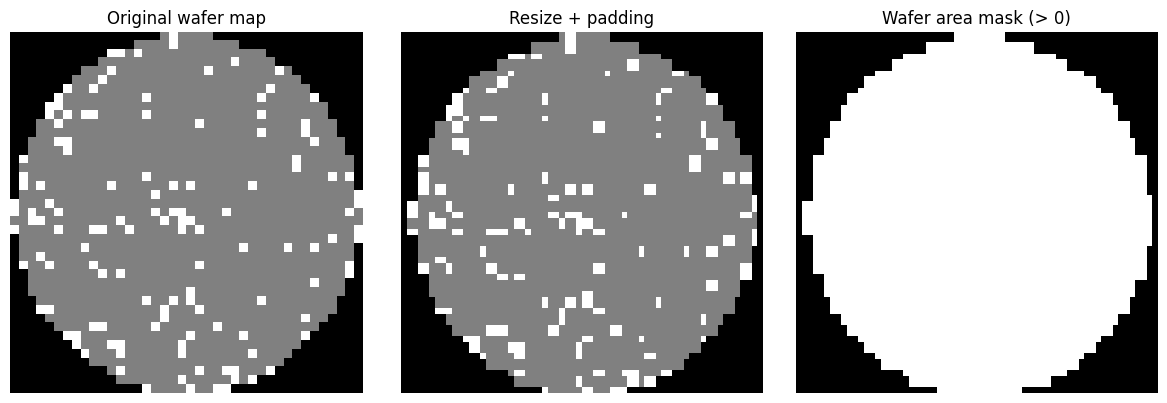

입력 shape: (41, 40)
패딩 후 shape: (64, 64)
mask의 wafer pixel 수: 3,031


In [30]:
import matplotlib.pyplot as plt


sample_wafer_map = np.asarray(train_df.iloc[0]["waferMap"], dtype=np.uint8)
sample_padded, sample_mask = preprocess_resize_pad_with_mask(
    sample_wafer_map,
    target_size=64,
)

expected_mask = (sample_padded > 0).astype(np.uint8)
assert np.array_equal(sample_mask, expected_mask)
assert set(np.unique(sample_mask).tolist()).issubset({0, 1})

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_wafer_map, cmap="gray", vmin=0, vmax=2)
axes[0].set_title("Original wafer map")
axes[1].imshow(sample_padded, cmap="gray", vmin=0, vmax=2)
axes[1].set_title("Resize + padding")
axes[2].imshow(sample_mask, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Wafer area mask (> 0)")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

print(f"입력 shape: {sample_wafer_map.shape}")
print(f"패딩 후 shape: {sample_padded.shape}")
print(f"mask의 wafer pixel 수: {int(sample_mask.sum()):,}")


In [31]:
class WaferDataset(Dataset):
    """웨이퍼 맵 데이터셋."""

    def __init__(
        self,
        images,
        labels,
        lot_names,
        transforms=None,
        resize_mode: str = "resize_pad",
        target_size: int = 64,
    ) -> None:
        """데이터셋을 초기화합니다.

        Args:
            images: 웨이퍼 맵 이미지 리스트 또는 배열.
            labels: 클래스 라벨 리스트 또는 배열.
            lot_names: lot 이름 리스트 또는 배열.
            transforms: 텐서 변환 함수.
            resize_mode: 전처리 방식.
                - "fixed_resize"
                - "resize_pad"
                - "resize_pad_mask"
            target_size: 목표 이미지 크기.
        """
        self.images = images
        self.labels = labels
        self.lot_names = lot_names
        self.transforms = transforms
        self.resize_mode = resize_mode
        self.target_size = target_size

    def __len__(self) -> int:
        """데이터셋 길이를 반환합니다."""
        return len(self.images)

    def __getitem__(self, idx: int):
        """인덱스에 해당하는 샘플 1건을 반환합니다.

        Args:
            idx: 데이터 인덱스.

        Returns:
            입력 텐서, 라벨, lot 이름.
        """
        x = self.images[idx]
        y = int(self.labels[idx])
        lot = self.lot_names[idx]

        if not isinstance(x, np.ndarray):
            x = np.array(x)

        x = x.astype(np.uint8)

        if self.resize_mode == "fixed_resize":
            x = preprocess_fixed_resize(x, self.target_size)
            x = torch.from_numpy(np.ascontiguousarray(x)).float().unsqueeze(0) / 2.0

        elif self.resize_mode == "resize_pad":
            x = preprocess_resize_pad(x, self.target_size)
            x = torch.from_numpy(np.ascontiguousarray(x)).float().unsqueeze(0) / 2.0

        elif self.resize_mode == "resize_pad_mask":
            padded, mask = preprocess_resize_pad_with_mask(x, self.target_size)
            padded = (
                torch.from_numpy(np.ascontiguousarray(padded))
                .float()
                .unsqueeze(0)
                / 2.0
            )
            mask = (
                torch.from_numpy(np.ascontiguousarray(mask))
                .float()
                .unsqueeze(0)
            )
            x = torch.cat([padded, mask], dim=0)

        else:
            raise ValueError(f"지원하지 않는 resize_mode: {self.resize_mode}")

        if self.transforms is not None:
            x = self.transforms(x)

        return x, y, lot

## 데이터로더 생성

In [32]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import pandas as pd
from sklearn.utils import resample
from torch.utils.data import DataLoader
import torchvision.transforms as T


def build_train_df(train_df: pd.DataFrame, use_oversampling: bool) -> pd.DataFrame:
    """학습용 데이터프레임을 생성합니다.

    학습 데이터에 대해서만 오버샘플링을 적용합니다.
    검증/테스트 데이터에는 적용하지 않습니다.

    Args:
        train_df: 원본 학습 데이터프레임.
        use_oversampling: 오버샘플링 적용 여부.

    Returns:
        오버샘플링이 반영된 학습 데이터프레임.
    """
    train_df = train_df.copy()

    if not use_oversampling:
        return train_df.reset_index(drop=True)

    class_counts = train_df["label_id"].value_counts()
    average_size = int(class_counts.mean())

    resampled_df_list = []

    for label in sorted(train_df["label_id"].unique()):
        class_df = train_df[train_df["label_id"] == label]

        resampled_df = resample(
            class_df,
            replace=True,
            n_samples=average_size,
            random_state=42,
        )
        resampled_df_list.append(resampled_df)

    balanced_train_df = pd.concat(resampled_df_list, axis=0)
    balanced_train_df = balanced_train_df.sample(frac=1.0, random_state=42)

    return balanced_train_df.reset_index(drop=True)

In [33]:
def build_train_transforms(use_augmentation: bool) -> Optional[T.Compose]:
    """학습용 증강 변환을 생성합니다.

    Args:
        use_augmentation: 증강 적용 여부.

    Returns:
        torchvision transform 또는 None.
    """
    if not use_augmentation:
        return None

    return T.Compose([
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
        T.RandomRotation(15),
    ])

In [34]:
def build_datasets(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    resize_mode: str,
    use_augmentation: bool,
    target_size: int = 64,
):
    """실험 설정에 맞는 Dataset 객체들을 생성합니다.

    Args:
        train_df: 학습 데이터프레임.
        val_df: 검증 데이터프레임.
        test_df: 테스트 데이터프레임.
        resize_mode: 전처리 모드.
            - "fixed_resize"
            - "resize_pad"
            - "resize_pad_mask"
        use_augmentation: 학습 데이터 증강 적용 여부.
        target_size: 입력 이미지 크기.

    Returns:
        train_dataset, val_dataset, test_dataset
    """
    train_transforms = build_train_transforms(use_augmentation=use_augmentation)

    train_dataset = WaferDataset(
        images=train_df["waferMap"].values,
        labels=train_df["label_id"].values,
        lot_names=train_df["lotName"].values,
        transforms=train_transforms,
        resize_mode=resize_mode,
        target_size=target_size,
    )

    val_dataset = WaferDataset(
        images=val_df["waferMap"].values,
        labels=val_df["label_id"].values,
        lot_names=val_df["lotName"].values,
        transforms=None,
        resize_mode=resize_mode,
        target_size=target_size,
    )

    test_dataset = WaferDataset(
        images=test_df["waferMap"].values,
        labels=test_df["label_id"].values,
        lot_names=test_df["lotName"].values,
        transforms=None,
        resize_mode=resize_mode,
        target_size=target_size,
    )

    return train_dataset, val_dataset, test_dataset

In [35]:
def build_dataloaders(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    resize_mode: str,
    use_oversampling: bool,
    use_augmentation: bool,
    batch_size: int = 32,
    target_size: int = 64,
    num_workers: int = 0,
):
    """실험 설정에 맞는 DataLoader를 생성합니다.

    Args:
        train_df: 학습 데이터프레임.
        val_df: 검증 데이터프레임.
        test_df: 테스트 데이터프레임.
        resize_mode: 전처리 모드.
        use_oversampling: 오버샘플링 적용 여부.
        use_augmentation: 증강 적용 여부.
        batch_size: 배치 크기.
        target_size: 입력 이미지 크기.
        num_workers: DataLoader 워커 수.

    Returns:
        train_loader, val_loader, test_loader
    """
    prepared_train_df = build_train_df(
        train_df=train_df,
        use_oversampling=use_oversampling,
    )

    train_dataset, val_dataset, test_dataset = build_datasets(
        train_df=prepared_train_df,
        val_df=val_df,
        test_df=test_df,
        resize_mode=resize_mode,
        use_augmentation=use_augmentation,
        target_size=target_size,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, val_loader, test_loader

## 실험 설정


In [36]:
from dataclasses import dataclass


@dataclass
class ExperimentConfig:
    """실험 설정 객체."""

    name: str
    resize_mode: str
    use_oversampling: bool
    use_augmentation: bool
    batch_size: int = 32
    target_size: int = 64
    epochs: int = 30
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    scheduler_patience: int = 3
    early_stopping_patience: int = 7

    @property
    def in_channels(self) -> int:
        """입력 채널 수를 반환합니다."""
        if self.resize_mode == "resize_pad_mask":
            return 2
        return 1

In [37]:
EXPERIMENTS = [
    ExperimentConfig(
        name="exp5_wafer_area_mask_os_aug",
        resize_mode="resize_pad_mask",
        use_oversampling=True,
        use_augmentation=True,
    ),
]

EXPERIMENTS


[ExperimentConfig(name='exp5_wafer_area_mask_os_aug', resize_mode='resize_pad_mask', use_oversampling=True, use_augmentation=True, batch_size=32, target_size=64, epochs=30, learning_rate=0.001, weight_decay=0.0001, scheduler_patience=3, early_stopping_patience=7)]

## 모델 학습

In [38]:
import copy
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm


def set_seed(seed: int = 42) -> None:
    """재현성을 위해 시드를 고정합니다.

    Args:
        seed: 랜덤 시드 값.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class EarlyStopping:
    """검증 성능 기준 조기 종료를 수행하는 클래스."""

    def __init__(self, patience: int = 7, mode: str = "max") -> None:
        """EarlyStopping 객체를 초기화합니다.

        Args:
            patience: 개선이 없을 때 허용할 epoch 수.
            mode: 성능 비교 방향. "max" 또는 "min".
        """
        self.patience = patience
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.should_stop = False

    def step(self, score: float) -> bool:
        """현재 점수를 바탕으로 조기 종료 여부를 갱신합니다.

        Args:
            score: 현재 epoch의 검증 점수.

        Returns:
            조기 종료 여부.
        """
        if self.best_score is None:
            self.best_score = score
            return False

        is_improved = (
            score > self.best_score
            if self.mode == "max"
            else score < self.best_score
        )

        if is_improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return self.should_stop


In [39]:
def train_one_epoch(
    model: nn.Module,
    loader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: torch.amp.GradScaler | None = None,
) -> Tuple[float, float, float, float]:
    """한 epoch 동안 학습을 수행합니다.

    Args:
        model: 학습할 모델.
        loader: 학습 데이터로더.
        criterion: 손실 함수.
        optimizer: 옵티마이저.
        device: 학습 장치.
        scaler: AMP용 GradScaler.

    Returns:
        평균 loss, macro f1, macro precision, macro recall
    """
    model.train()

    running_loss = 0.0
    all_preds: List[int] = []
    all_targets: List[int] = []

    use_amp = device.type == "cuda"

    for inputs, targets, _ in tqdm(loader, desc="Train", leave=False):
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        if use_amp and scaler is not None:
            with torch.amp.autocast(device_type=device.type):
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_precision = precision_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )
    epoch_recall = recall_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )

    return epoch_loss, epoch_f1, epoch_precision, epoch_recall


In [40]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader,
    criterion: nn.Module,
    device: torch.device,
    phase: str = "Val",
) -> Tuple[float, float, float, float]:
    """검증 또는 테스트 평가를 수행합니다.

    Args:
        model: 평가할 모델.
        loader: 검증/테스트 데이터로더.
        criterion: 손실 함수.
        device: 평가 장치.
        phase: 진행 단계 이름.

    Returns:
        평균 loss, macro f1, macro precision, macro recall
    """
    model.eval()

    running_loss = 0.0
    all_preds: List[int] = []
    all_targets: List[int] = []

    use_amp = device.type == "cuda"

    for inputs, targets, _ in tqdm(loader, desc=phase, leave=False):
        inputs = inputs.to(device)
        targets = targets.to(device)

        if use_amp:
            with torch.amp.autocast(device_type=device.type):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_precision = precision_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )
    epoch_recall = recall_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )

    return epoch_loss, epoch_f1, epoch_precision, epoch_recall


In [41]:
import os

def process(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    experiment_config: ExperimentConfig,
    num_classes: int,
    device: torch.device | None = None,
    seed: int = 42,
    save_dir: str | Path = CHECKPOINT_DIR,
) -> Dict[str, float]:
    """실험 설정 기반 모델 학습 및 평가를 수행합니다.

    Args:
        train_df: 학습 데이터프레임.
        val_df: 검증 데이터프레임.
        test_df: 테스트 데이터프레임.
        experiment_config: 실험 설정 객체.
        num_classes: 클래스 개수.
        device: 학습 장치.
        seed: 랜덤 시드 값.
        save_dir: 이 실험 전용 체크포인트 저장 경로.

    Returns:
        실험 결과 딕셔너리.
    """
    set_seed(seed)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"\n===== {experiment_config.name} 시작 =====")
    print(f"resize_mode: {experiment_config.resize_mode}")
    print(f"use_oversampling: {experiment_config.use_oversampling}")
    print(f"use_augmentation: {experiment_config.use_augmentation}")
    print(f"in_channels: {experiment_config.in_channels}")
    print(f"device: {device}")

    train_loader, val_loader, test_loader = build_dataloaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        resize_mode=experiment_config.resize_mode,
        use_oversampling=experiment_config.use_oversampling,
        use_augmentation=experiment_config.use_augmentation,
        batch_size=experiment_config.batch_size,
        target_size=experiment_config.target_size,
        num_workers=0,
    )

    model = SmallCNN(
        num_classes=num_classes,
        in_channels=experiment_config.in_channels,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(
        model.parameters(),
        lr=experiment_config.learning_rate,
        weight_decay=experiment_config.weight_decay,
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=experiment_config.scheduler_patience,
    )
    early_stopping = EarlyStopping(
        patience=experiment_config.early_stopping_patience,
        mode="max",
    )

    scaler = torch.amp.GradScaler() if device.type == "cuda" else None

    best_val_f1 = -1.0
    best_model_state = copy.deepcopy(model.state_dict())
    history: List[Dict[str, float]] = []

    for epoch in range(1, experiment_config.epochs + 1):
        train_loss, train_f1, train_precision, train_recall = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            scaler=scaler,
        )

        val_loss, val_f1, val_precision, val_recall = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            phase="Val",
        )

        scheduler.step(val_f1)

        current_lr = optimizer.param_groups[0]["lr"]

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_f1": train_f1,
                "train_precision": train_precision,
                "train_recall": train_recall,
                "val_loss": val_loss,
                "val_f1": val_f1,
                "val_precision": val_precision,
                "val_recall": val_recall,
                "lr": current_lr,
            }
        )

        print(
            f"[{experiment_config.name}] "
            f"Epoch {epoch:02d}/{experiment_config.epochs} | "
            f"Train Loss: {train_loss:.4f}, Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}, "
            f"Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())

            Path(save_dir).mkdir(parents=True, exist_ok=True)
            save_path = Path(save_dir) / f"{experiment_config.name}.pt"

            torch.save(
                {
                    "model_state_dict": best_model_state,
                    "config": experiment_config.__dict__,
                    "best_val_f1": best_val_f1,
                },
                save_path,
            )

            print(f"[{experiment_config.name}] 모델 저장 완료 → {save_path}")

        if early_stopping.step(val_f1):
            print(
                f"[{experiment_config.name}] "
                f"Early stopping 발동 (epoch={epoch})"
            )
            break

    model.load_state_dict(best_model_state)

    test_loss, test_f1, test_precision, test_recall = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device,
        phase="Test",
    )

    print(
        f"[{experiment_config.name}] TEST | "
        f"Loss: {test_loss:.4f}, "
        f"F1: {test_f1:.4f}, "
        f"Precision: {test_precision:.4f}, "
        f"Recall: {test_recall:.4f}"
    )

    result = {
        "experiment": experiment_config.name,
        "resize_mode": experiment_config.resize_mode,
        "use_oversampling": experiment_config.use_oversampling,
        "use_augmentation": experiment_config.use_augmentation,
        "in_channels": experiment_config.in_channels,
        "best_val_f1": best_val_f1,
        "test_loss": test_loss,
        "test_macro_f1": test_f1,
        "test_macro_precision": test_precision,
        "test_macro_recall": test_recall,
        "history": history,
    }

    return result


## 실험 수행

In [42]:
def run_all_experiments(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    experiments: List[ExperimentConfig],
    num_classes: int,
    device: torch.device | None = None,
    seed: int = 42,
    save_dir: str | Path = CHECKPOINT_DIR,
) -> pd.DataFrame:
    """전체 실험을 순차적으로 실행합니다.

    Args:
        train_df: 학습 데이터프레임.
        val_df: 검증 데이터프레임.
        test_df: 테스트 데이터프레임.
        experiments: 실험 설정 리스트.
        num_classes: 클래스 개수.
        device: 학습 장치.
        seed: 랜덤 시드 값.
        save_dir: 이 실험 전용 체크포인트 저장 경로.

    Returns:
        실험 결과 요약 데이터프레임.
    """
    all_results = []

    for experiment_config in experiments:
        result = process(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            experiment_config=experiment_config,
            num_classes=num_classes,
            device=device,
            seed=seed,
            save_dir=save_dir,
        )
        all_results.append(result)

    results_df = pd.DataFrame(
        [
            {
                "experiment": result["experiment"],
                "resize_mode": result["resize_mode"],
                "use_oversampling": result["use_oversampling"],
                "use_augmentation": result["use_augmentation"],
                "in_channels": result["in_channels"],
                "best_val_f1": result["best_val_f1"],
                "test_loss": result["test_loss"],
                "test_macro_f1": result["test_macro_f1"],
                "test_macro_precision": result["test_macro_precision"],
                "test_macro_recall": result["test_macro_recall"],
            }
            for result in all_results
        ]
    )

    return results_df

## 실험 수행

다음 셀이 실제 딥러닝 학습을 시작합니다. 요청에 따라 이 노트북을 생성하는 과정에서는 실행하지 않았습니다. 직접 실행할 때만 새 artifact 디렉터리와 체크포인트가 만들어집니다.


In [43]:
NUM_CLASSES = len(CLASSES)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"학습 장치: {device}")
print(f"체크포인트 저장 위치: {CHECKPOINT_DIR}")

results_df = run_all_experiments(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    experiments=EXPERIMENTS,
    num_classes=NUM_CLASSES,
    device=device,
    save_dir=CHECKPOINT_DIR,
)

results_df


학습 장치: cuda
체크포인트 저장 위치: /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/mask_wafer_area_experiment/checkpoints

===== exp5_wafer_area_mask_os_aug 시작 =====
resize_mode: resize_pad_mask
use_oversampling: True
use_augmentation: True
in_channels: 2
device: cuda


Train:   0%|          | 0/4378 [00:00<?, ?it/s]

Val:   0%|          | 0/487 [00:00<?, ?it/s]

[exp5_wafer_area_mask_os_aug] Epoch 01/30 | Train Loss: 0.6071, Train F1: 0.7805 | Val Loss: 1.3316, Val F1: 0.5548, Val Precision: 0.5102, Val Recall: 0.8141 | LR: 0.001000
[exp5_wafer_area_mask_os_aug] 모델 저장 완료 → /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/mask_wafer_area_experiment/checkpoints/exp5_wafer_area_mask_os_aug.pt


Train:   0%|          | 0/4378 [00:00<?, ?it/s]

...

Val:   0%|          | 0/487 [00:00<?, ?it/s]

[exp5_wafer_area_mask_os_aug] Epoch 21/30 | Train Loss: 0.1943, Train F1: 0.9341 | Val Loss: 0.2053, Val F1: 0.8146, Val Precision: 0.7624, Val Recall: 0.9082 | LR: 0.000500
[exp5_wafer_area_mask_os_aug] Early stopping 발동 (epoch=21)


Test:   0%|          | 0/541 [00:00<?, ?it/s]

[exp5_wafer_area_mask_os_aug] TEST | Loss: 0.1865, F1: 0.8205, Precision: 0.7679, Recall: 0.8926


,experiment,resize_mode,use_oversampling,use_augmentation,in_channels,best_val_f1,test_loss,test_macro_f1,test_macro_precision,test_macro_recall
0,exp5_wafer_area_mask_os_aug,resize_pad_mask,True,True,2,0.839209,0.186483,0.820473,0.767925,0.892568


In [44]:
results_df.sort_values(
    by="test_macro_f1",
    ascending=False,
).reset_index(drop=True)


,experiment,resize_mode,use_oversampling,use_augmentation,in_channels,best_val_f1,test_loss,test_macro_f1,test_macro_precision,test_macro_recall
0,exp5_wafer_area_mask_os_aug,resize_pad_mask,True,True,2,0.839209,0.186483,0.820473,0.767925,0.892568


In [45]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(RESULTS_PATH, index=False)
print(f"결과 저장 완료: {RESULTS_PATH}")


결과 저장 완료: /content/drive/MyDrive/Colab Notebooks/SKALA/wafer_v2/mask_wafer_area_experiment/results_wafer_area_mask.csv


### 단일 실험만 수행

이 노트북의 `EXPERIMENTS`에는 corrected wafer-area mask 실험 하나만 들어 있습니다.


In [46]:
# 설정을 먼저 확인한 뒤 위의 "실험 수행" 셀을 실행하세요.
EXPERIMENTS[0]


ExperimentConfig(name='exp5_wafer_area_mask_os_aug', resize_mode='resize_pad_mask', use_oversampling=True, use_augmentation=True, batch_size=32, target_size=64, epochs=30, learning_rate=0.001, weight_decay=0.0001, scheduler_patience=3, early_stopping_patience=7)

## 기존 모델과 validation 성능 비교

기존 `results.csv`는 읽기만 합니다. 잘못된 사각형 mask를 사용한 `exp5_resize_pad_mask_os_aug`는 비교 대상에서 제외하고, 기존 실험 1~4와 이 노트북에서 학습한 corrected wafer-area mask 실험을 합쳐 표시합니다.


,experiment,best_val_f1,test_loss,test_macro_f1,test_macro_precision,test_macro_recall
0,exp4_resize_pad_os_aug,0.848053,0.160896,0.843600,0.811501,0.887790
1,exp3_resize_pad_with_aug,0.841027,0.092143,0.845027,0.889984,0.814120
2,exp1_fixed_resize_no_aug,0.840572,0.103413,0.854152,0.888881,0.828599
3,exp5_wafer_area_mask_os_aug,0.839209,0.186483,0.820473,0.767925,0.892568
4,exp2_resize_pad_no_aug,0.831303,0.097752,0.839562,0.883047,0.806789


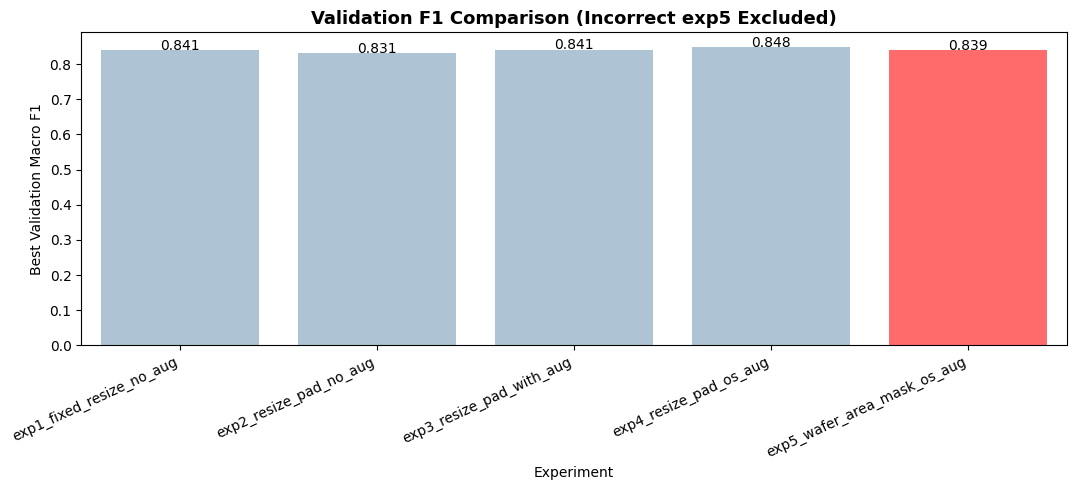

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns


LEGACY_RESULTS_PATH = WORK_DIR / "results.csv"
EXCLUDED_EXPERIMENT = "exp5_resize_pad_mask_os_aug"
COMPARISON_COLUMNS = [
    "experiment",
    "best_val_f1",
    "test_loss",
    "test_macro_f1",
    "test_macro_precision",
    "test_macro_recall",
]

if not LEGACY_RESULTS_PATH.is_file():
    raise FileNotFoundError(
        f"기존 실험 결과를 찾지 못했습니다: {LEGACY_RESULTS_PATH}"
    )

legacy_results_df = pd.read_csv(LEGACY_RESULTS_PATH)
legacy_results_without_exp5 = legacy_results_df.loc[
    legacy_results_df["experiment"] != EXCLUDED_EXPERIMENT
].copy()

comparison_results_df = pd.concat(
    [legacy_results_without_exp5, results_df],
    ignore_index=True,
)
comparison_results_df = comparison_results_df.drop_duplicates(
    subset="experiment",
    keep="last",
)

assert EXCLUDED_EXPERIMENT not in comparison_results_df["experiment"].values

comparison_table = comparison_results_df[COMPARISON_COLUMNS].sort_values(
    by="best_val_f1",
    ascending=False,
).reset_index(drop=True)
display(comparison_table)

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=comparison_results_df,
    x="experiment",
    y="best_val_f1",
    color="#A8C5DA",
)

corrected_experiment = EXPERIMENTS[0].name
for patch, experiment_name in zip(
    ax.patches,
    comparison_results_df["experiment"],
):
    if experiment_name == corrected_experiment:
        patch.set_facecolor("#FF6B6B")

for index, value in enumerate(comparison_results_df["best_val_f1"]):
    ax.text(index, value + 0.001, f"{value:.3f}", ha="center", fontsize=10)

plt.title(
    "Validation F1 Comparison (Incorrect exp5 Excluded)",
    fontsize=13,
    weight="bold",
)
plt.ylabel("Best Validation Macro F1")
plt.xlabel("Experiment")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


불러온 config:
{'name': 'exp5_wafer_area_mask_os_aug', 'resize_mode': 'resize_pad_mask', 'use_oversampling': True, 'use_augmentation': True, 'batch_size': 32, 'target_size': 64, 'epochs': 30, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'scheduler_patience': 3, 'early_stopping_patience': 7}
Test Macro F1: 0.8204
Test Macro Precision: 0.7678
Test Macro Recall: 0.8926

[Classification Report]
              precision    recall  f1-score   support

      Center     0.7774    0.9441    0.8526       429
       Donut     0.7500    0.9107    0.8226        56
    Edge-Loc     0.6496    0.8574    0.7392       519
   Edge-Ring     0.9526    0.9762    0.9643       968
         Loc     0.6950    0.6156    0.6529       359
      Random     0.6612    0.9195    0.7692        87
     Scratch     0.5495    0.8403    0.6645       119
   Near-full     0.8824    1.0000    0.9375        15
        none     0.9928    0.9691    0.9808     14743

    accuracy                         0.9569     17295
   macro a

<Figure size 1000x800 with 0 Axes>

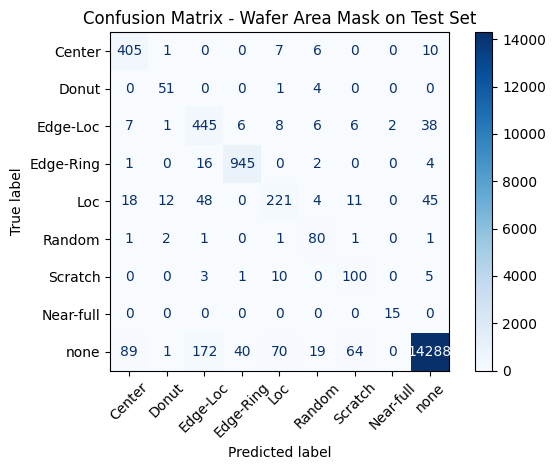

In [48]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

# 클래스 이름
CLASSES = [
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
    "none",
]

ID2LABEL = {idx: label for idx, label in enumerate(CLASSES)}


@torch.no_grad()
def predict_on_loader(
    model: torch.nn.Module,
    loader,
    device: torch.device,
) -> tuple[list[int], list[int], list[str]]:
    """데이터로더 전체에 대해 예측 결과를 수집합니다.

    Args:
        model: 학습된 모델.
        loader: 평가용 데이터로더.
        device: 연산 장치.

    Returns:
        실제 라벨 리스트, 예측 라벨 리스트, lot 이름 리스트
    """
    model.eval()

    all_targets = []
    all_preds = []
    all_lots = []

    for inputs, targets, lots in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_targets.extend(targets.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_lots.extend(list(lots))

    return all_targets, all_preds, all_lots


def load_experiment_model(
    checkpoint_path: str | Path,
    num_classes: int,
    device: torch.device,
) -> tuple[torch.nn.Module, dict]:
    """저장된 체크포인트에서 모델을 복원합니다.

    Args:
        checkpoint_path: 체크포인트 경로.
        num_classes: 클래스 개수.
        device: 연산 장치.

    Returns:
        복원된 모델, 체크포인트 내부 config
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)

    config = checkpoint["config"]
    in_channels = 2 if config["resize_mode"] == "resize_pad_mask" else 1

    model = SmallCNN(
        num_classes=num_classes,
        in_channels=in_channels,
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, config


# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 이 노트북에서 새로 생성한 체크포인트만 사용
checkpoint_path = CHECKPOINT_DIR / f"{EXPERIMENTS[0].name}.pt"

# 체크포인트 로드
model, loaded_config = load_experiment_model(
    checkpoint_path=checkpoint_path,
    num_classes=len(CLASSES),
    device=device,
)

print("불러온 config:")
print(loaded_config)

# 새 mask 실험 설정에 맞는 test_loader 다시 생성
_, _, test_loader = build_dataloaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    resize_mode=loaded_config["resize_mode"],          # 이 실험은 resize_pad_mask
    use_oversampling=loaded_config["use_oversampling"],# test에는 영향 없음
    use_augmentation=False,                            # test에는 augmentation 미적용
    batch_size=32,
    target_size=loaded_config["target_size"],
    num_workers=0,
)

# 예측 수집
y_true, y_pred, lot_names = predict_on_loader(
    model=model,
    loader=test_loader,
    device=device,
)

# 전체 성능 확인
test_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
test_macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Macro Precision: {test_macro_precision:.4f}")
print(f"Test Macro Recall: {test_macro_recall:.4f}")

# classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASSES,
    digits=4,
    zero_division=0,
)

print("\n[Classification Report]")
print(report)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix - Wafer Area Mask on Test Set")
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

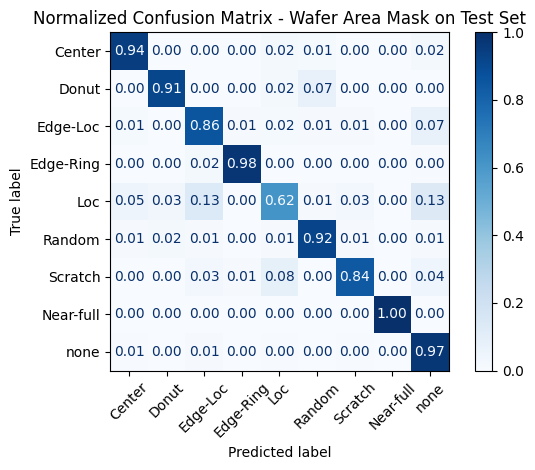

In [49]:
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45, values_format=".2f")
plt.title("Normalized Confusion Matrix - Wafer Area Mask on Test Set")
plt.tight_layout()
plt.show()